## Preprocesamiento de los datos para Machine Learning

Aplicar las técnicas principales de preprocesamiento de datos para preparar un dataset antes del entrenamiento.

## Parte 1. Comprensión del problema

Trabajeremos con el Dataset de Titanic, para construir un modelo que sea capaz de predecir si una persona sobrevive o no. 

In [2]:
# importamos las librerias
import pandas as pd
import numpy as np

#Librerias de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

In [3]:
#Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path #Imprimimos la ruta

'/Users/mareinazarate/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1'

In [4]:
dfTitanic =  pd.read_csv(path + "/Titanic-Dataset.csv") #Creamos el Dataframe

In [5]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
dfTitanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Parte 2. Seleccion de Variables Predictoras y Variable Objetivo

La variable objetivo sera: Survived

donde: 0 = No sobrevivio 1 = Sobrevivio

In [7]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [10]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis

Vamos a identificar la relación entre variables númericas.

nota: La correlacion NO representa la importancia REAL de la variable en el modelo.

In [11]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [13]:
corr =  dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


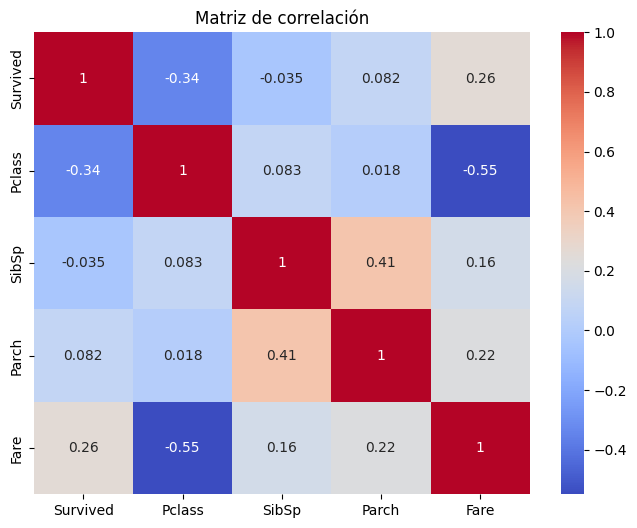

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

## Parte 4. Variables predictoras.

X --> Aquellas varaibles que nos ayudan a predecir
y --> Varaiable objetivo


In [15]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [16]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

In [17]:
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [18]:
X.columns #Predictoras

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='str')

In [19]:
y.name #Objetivo

'Survived'

In [ ]:
## Parte 5. Limpieza de los datos

Realizaremos la imputación de los datos, donde existan valores nulos.
    

In [20]:
# Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [21]:
#vamos a imputar los datos para el campo Edad, calculando la mediana
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

In [22]:
#Vamos imputar los datos para el campo Embarked, calculando la moda
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

In [23]:
# Revisamos si existen valores nulos
X.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

In [ ]:
## Parte 6: Normalizamos los datos categoricos (texto) 

 Los algoritmos de ML no entienden texto.

In [25]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [26]:
#One Hot Encoding
X= pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True
)

In [27]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. División de los datos

No debemos entrenar y evaluar utilizando los mismos datos.

80% para entrenar

20% para evaluar
    

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
print("Entrenamiento X: ", X_train.shape)

Entrenamiento X:  (712, 6)


In [34]:
print("Prueba X: ", X_test.shape)

Prueba X:  (179, 6)


In [35]:
print("Entrenamiento Y: ", y_train.shape)

Entrenamiento Y:  (712,)


In [36]:
print("Prueba Y: ", y_test.shape)

Prueba Y:  (179,)
